## Cell 1: Select Video

Pick a video by its id from `data/manifests/videos.yaml`. The manifest resolves the path automatically — local files are used directly, remote sources (Google Drive, OneDrive) will be downloaded once that integration is wired up.

In [1]:
from pipeline.io import find_video, resolve_video_path, create_run
from pipeline import config

VIDEO_ID = "crossing_001"  # ← change this to switch videos

entry      = find_video(VIDEO_ID)
video_path = resolve_video_path(entry)

config.MODEL_PATH = "weights/best.pt"

print(f"Video ID  : {entry.id}")
print(f"Name      : {entry.name}")
print(f"Video     : {video_path}")
print(f"Model     : {config.MODEL_PATH}")

Video ID  : crossing_001
Name      : Sample railroad crossing video
Video     : data/cache/crossing_001.mp4
Model     : weights/best.pt


## Cell 2: Define Zone of Interest

Adjust the corner coordinates using the grid, then re-run. Values are written to config.ZOI_POINTS so the pipeline picks them up automatically.

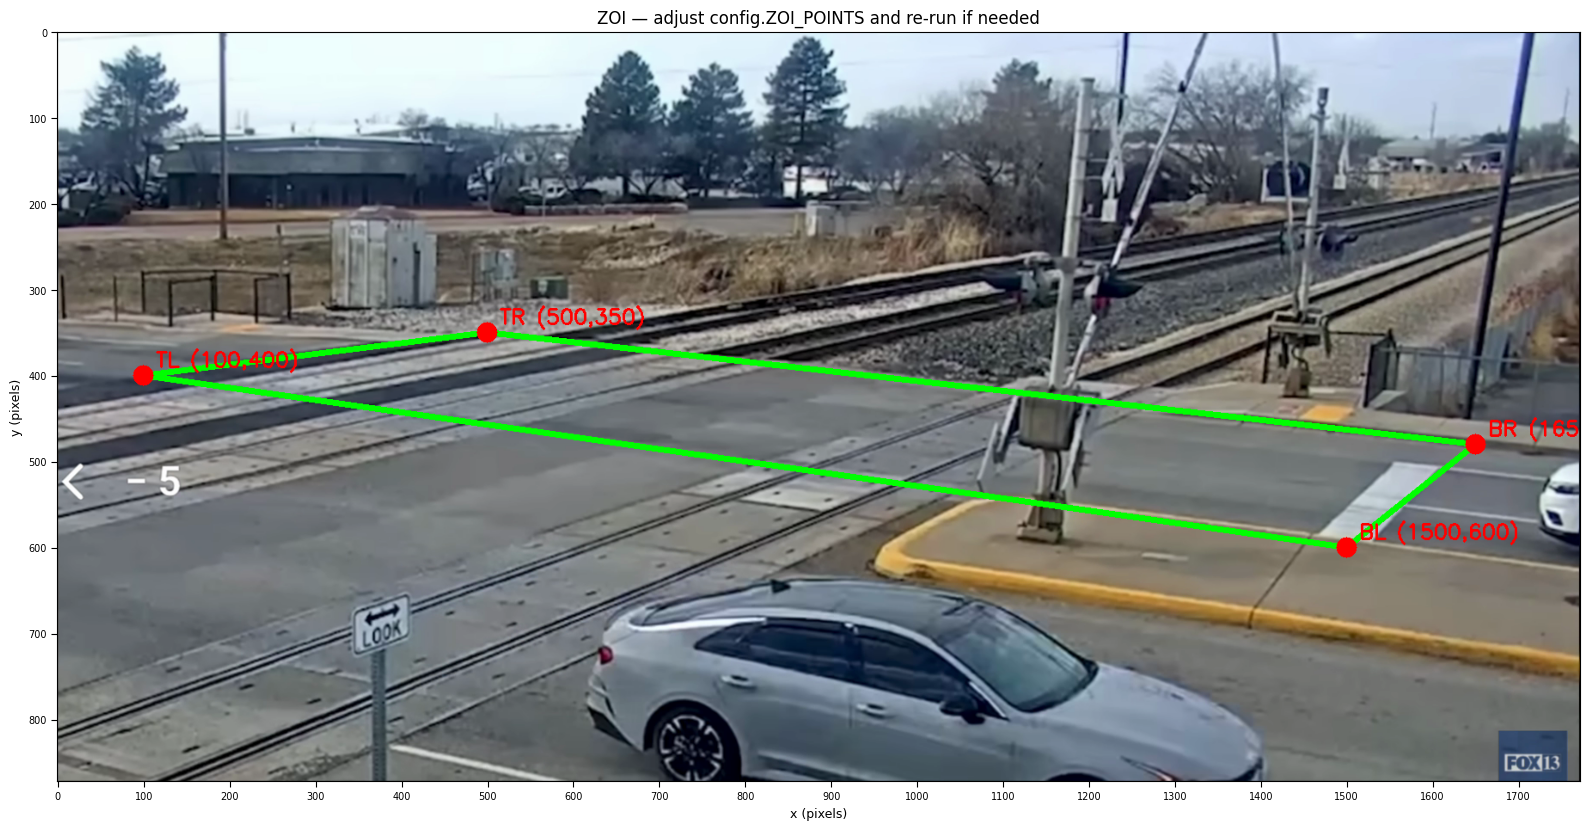

ZOI points: [[100, 400], [500, 350], [1650, 480], [1500, 600]]


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(config.VIDEO_PATH)
ret, frame = cap.read()
cap.release()

# ZOI points are defined in pipeline/config.py — edit there to adjust.
zoi_points = np.array(config.ZOI_POINTS, dtype=np.int32)
frame_zoi = frame.copy()
h, w = frame_zoi.shape[:2]

# Draw ZOI polygon and corner markers on the frame only
cv2.polylines(frame_zoi, [zoi_points], isClosed=True, color=(0, 255, 0), thickness=5)
for pt, lbl in zip(zoi_points, ["TL", "TR", "BR", "BL"]):
    x, y = pt
    cv2.circle(frame_zoi, (x, y), 12, (0, 0, 255), -1)
    cv2.putText(frame_zoi, f"{lbl} ({x},{y})", (x + 15, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

fig, ax = plt.subplots(figsize=(16, 9))
ax.imshow(cv2.cvtColor(frame_zoi, cv2.COLOR_BGR2RGB))

# Pixel coordinate ticks outside the frame
ax.set_xticks(range(0, w + 1, 100))
ax.set_yticks(range(0, h + 1, 100))
ax.tick_params(axis="both", labelsize=7, length=4)
ax.set_xlabel("x (pixels)", fontsize=9)
ax.set_ylabel("y (pixels)", fontsize=9)
ax.set_title("ZOI — adjust ZOI_POINTS in pipeline/config.py and re-run if needed", fontsize=12)

plt.tight_layout()
plt.show()
print(f"ZOI points: {config.ZOI_POINTS}")


## Cell 3: Load Model

In [3]:
from ultralytics import YOLO

model = YOLO(config.MODEL_PATH)
print(f"Model loaded: {config.MODEL_PATH}")
print(f"Classes: {list(model.names.values())}")

Model loaded: weights/best.pt
Classes: ['Car', 'Jeep', 'Motorcycle', 'Tricycle', 'Truck', 'Van']


## Cell 4: Run Pipeline

Creates an isolated run folder under `outputs/runs/`, then runs the full pipeline. All results (annotated video, CSVs, JSON, debug frames) are written there automatically.

In [4]:
from pipeline.io import save_run_results
from pipeline.runner import run_pipeline

run_paths = create_run(VIDEO_ID)

result = run_pipeline(
    video_path=video_path,
    model=model,
    zoi_points=np.array(config.ZOI_POINTS, dtype=np.int32),
    run_label=entry.name,
    run_paths=run_paths,
)

save_run_results(
    result,
    run_paths,
    run_metadata={"video_id": entry.id, "video_path": video_path, "model_path": config.MODEL_PATH},
    config_snapshot={
        "video_path":        video_path,
        "model_path":        config.MODEL_PATH,
        "area_threshold":    config.AREA_THRESHOLD,
        "time_threshold":    config.TIME_THRESHOLD,
        "vehicle_threshold": config.VEHICLE_THRESHOLD,
        "yolo_stride":       config.YOLO_STRIDE,
    },
)

print(f"Run complete — outputs saved to: {run_paths.run_dir}")

Run complete — outputs saved to: outputs/runs/crossing_001_2026-06-01_2106


## Cell 5: Display Snapshots

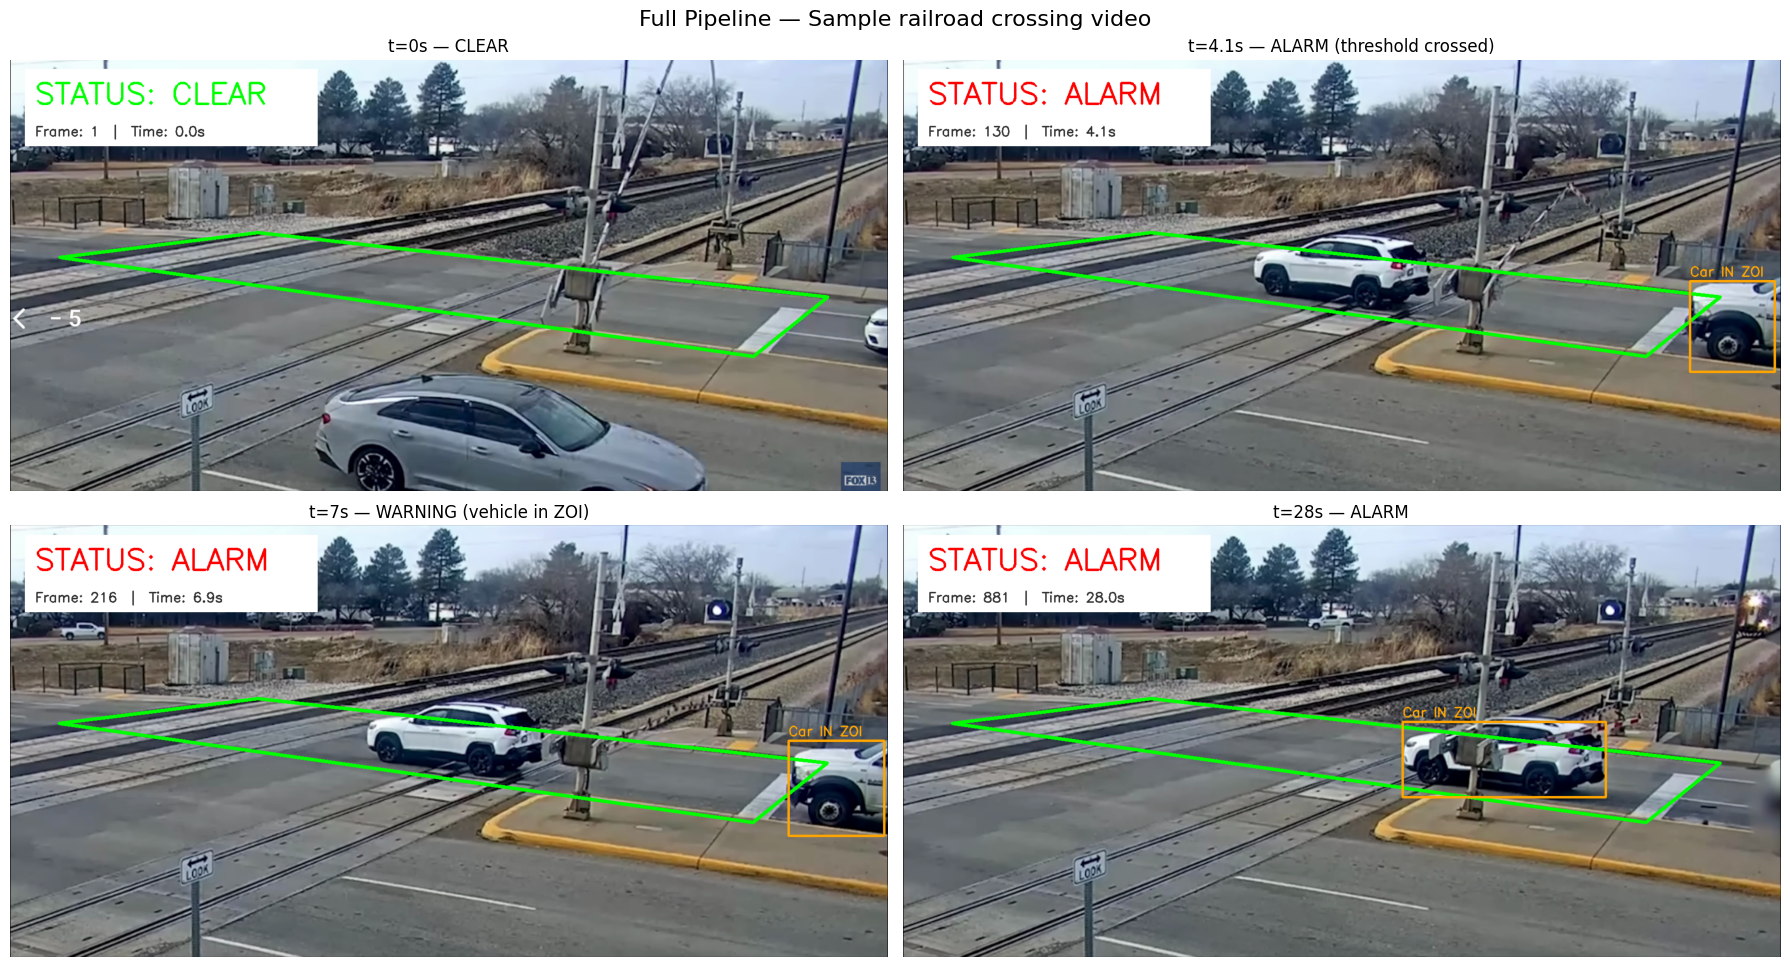

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.ravel()

for i, (label, img) in enumerate(result.snapshots.items()):
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=12)
    axes[i].axis("off")

plt.suptitle(f"Full Pipeline — {result.run_label}", fontsize=16)
plt.tight_layout()
plt.show()